# LSM Benchmarking with TCSPC

## Goal


## Approach & Measurement Setup




### .PTU Decoding

Function routines for decoding PicoQuant .ptu files.

In [2]:
%reset -f

# Importing modules
import sys, struct, io, os
import math
import numpy as np
from numba import jit
import scipy.signal as signal
import matplotlib.pyplot as plt
%matplotlib inline

# Setting up matplotlib for larger plots and retina resolution
from matplotlib import rcParams
%config InlineBackend.figure_format='retina'
rcParams['figure.figsize'] = (10, 8)
rcParams['legend.fontsize']  = 16
rcParams['axes.labelsize'] = 16


# File path to .ptu file to be analysed
#ptupath = '../notebooks/data/HyD_LongTime_Test_12.ptu'
#ptupath = '../app/testData/Convalaria_for_CC_6_1.ptu'
#ptupath = '../app/testData/Coumarin6_18_1.ptu'
#ptupath = '../notebooks/data/191126_DNA_FRETStandard_Lo_2_1.ptu'
#ptupath = '../notebooks/data/20191126_DNA-FRFET-Probe-high_stock_1_1.ptu'
ptupath = '../notebooks/data/TK-E-R51_CMV-mCh-R54_120minNCS_7_1.ptu'

In [40]:
# Functions for ptu record decoding
@jit(nopython=True, cache=True)
def treatOverflows(recordarray, macrotimefactor):
    '''
    Function treatOverflows(
    recordarray: 4 x numRec NumPy array holding raw 32 bit photon records in ['record']
    macrotimefactor: multiplication factor for mactotime clock to recover real experiment macrotime
    )
    Output is recordarray, but with populated ['macrotime'] row
    
    Takes whole record array and recovers real macrotime from raw photon TTTR data by adding
    number of macrotime clock overflows. See PicoQuant PTU documentary for further details and explanation.
    '''
    
    overflow_period = 1024
    overflow_cor = 0

    for record in recordarray:
        if(record['marker'] == 127):
            overflow_cor += overflow_period * \
                (record['record'] & (2**10 - 1))

        record['macrotime'] = (overflow_cor + np.bitwise_and(record['record'], 2**10-1)) * macrotimefactor
            
    return(recordarray)


In [162]:
# Record and header type definitions
tyEmpty8      = struct.unpack(">i", bytes.fromhex("FFFF0008"))[0]
tyBool8       = struct.unpack(">i", bytes.fromhex("00000008"))[0]
tyInt8        = struct.unpack(">i", bytes.fromhex("10000008"))[0]
tyBitSet64    = struct.unpack(">i", bytes.fromhex("11000008"))[0]
tyColor8      = struct.unpack(">i", bytes.fromhex("12000008"))[0]
tyFloat8      = struct.unpack(">i", bytes.fromhex("20000008"))[0]
tyTDateTime   = struct.unpack(">i", bytes.fromhex("21000008"))[0]
tyFloat8Array = struct.unpack(">i", bytes.fromhex("2001FFFF"))[0]
tyAnsiString  = struct.unpack(">i", bytes.fromhex("4001FFFF"))[0]
tyWideString  = struct.unpack(">i", bytes.fromhex("4002FFFF"))[0]
tyBinaryBlob  = struct.unpack(">i", bytes.fromhex("FFFFFFFF"))[0]

rtHydraHarp2T3 = struct.unpack(">i", bytes.fromhex('01010304'))[0]


#@jit(nopython = True, cache = True)
def readPTUData(path, makeFLIMInfo = True):

    # Open file defined in ptupath
    ptureadstream = open(path, 'rb')

    # Checking file magic and version
    filemagic = ptureadstream.read(8).decode('utf8').strip('\0')

    if(filemagic != 'PQTTTR'):
        print('%s is not a .ptu file!' % ptupath)
        ptureadstream.close()
    #else:
        #print('%s is a valid .ptu file... Commencing.' % ptupath)

    fileversion = ptureadstream.read(8).decode('utf8').strip('\0')
    #print('File Version: %s' % fileversion)


    ## Decoding Header
    ## setting up header end string to terminate header decoding in while loop 
    headerend_tag = 'Header_End'
    reached_headerend = False


    # tuple that stores decoded information from header section
    header_contents = {}

    # decoding header
    while(reached_headerend == False):
        headerpiece = ptureadstream.read(48)
        tagId = headerpiece[0:32].decode('latin1').strip('\0') # Necessary for non-US computer systems (If I remember correcly..., otherwise utf-8 encoding)
        tagIdx = struct.unpack('<i', headerpiece[32:36])[0]
        tagType = struct.unpack('<i', headerpiece[36:40])[0]
        tagVal = headerpiece[40:48]

        if(tagId == headerend_tag):
            reached_headerend = True
            ptureadstream.read(4) # Offset required so that photon records (see second part) are 'in frame'!
            #print('Found Header_End.')
            break

        if(tagType == tyEmpty8):
            header_contents['Empty'] =  'Empty'

        elif(tagType == tyBool8):
            value = struct.unpack('<q', tagVal)[0]
            header_contents[tagId] =  value

        elif(tagType == tyInt8):
            value = struct.unpack('<q', tagVal)[0]
            header_contents[tagId] =  value

        elif(tagType == tyFloat8):
            value = struct.unpack('<d', tagVal)[0]
            header_contents[tagId] =  value

        elif(tagType == tyFloat8Array):
            value = struct.unpack("<q", tagVal)[0]
            #print('Float array with %d entries' % value / 8)

        elif(tagType == tyAnsiString):
            value = struct.unpack('<q', tagVal)[0]
            string = ptureadstream.read(value).decode('latin1').strip('\0')
            header_contents[tagId] =  string

        elif(tagType == tyWideString):
            value = struct.unpack('<q', tagVal)[0]
            string = ptureadstream.read(value).decode('utf-16-le').strip('\0')
            header_contents[tagId] =  string

        elif(tagType == tyBinaryBlob):
            value = struct.unpack("<q", tagVal)[0]
            header_contents[tagId] =  value

        elif(tagType == tyBitSet64):
            value = struct.unpack('<q', tagVal)[0]
            header_contents[tagId] =  value

        elif(tagType == tyColor8):
            value = struct.unpack('<q', tagVal)[0]
            header_contents[tagId] =  "{0:#0{1}x}".format(value,18)

        elif(tagType == tyBinaryBlob):
            value = struct.unpack('<q', tagVal)[0]
            header_contents[tagId] =  value

        elif(tagType == tyTDateTime):
            print('')

        else:
            continue
            #print('Unknown header tag type. Ignored.')


    headerend_bitoffset = ptureadstream.tell() # Needed to quickly jump to photon records instead of header

    #print('Finished decoding header.')

    # Copying header info into FLIMInfo dict
    FLIMInfo = {
        #'Filename' : header_contents['$Filename'],
        #'Comment': header_contents['$Comment'],
        'RecordType' : header_contents['TTResultFormat_TTTRRecType'],
        'BitsPerRecord' : header_contents['TTResultFormat_BitsPerRecord'],
        #'PixelResolution' : header_contents['$ReqHdr_SpatialResolution'],
        'PixelsX' : header_contents['ImgHdr_PixX'],
        'PixelsY' : header_contents['ImgHdr_PixY'],
        'GlobalResolution' : header_contents['MeasDesc_GlobalResolution'],
        'BaseResolution' : header_contents['HW_BaseResolution'],
        'Resolution' : header_contents['MeasDesc_Resolution'],
        'BinningFactor' : header_contents['MeasDesc_BinningFactor'],
        'SyncRate' : header_contents['TTResult_SyncRate'],
        'NumberOfRecords' : header_contents['TTResult_NumberOfRecords']
    }

    # Closing read stream
    ptureadstream.close()


    # Reading photon records from ptu file, reopening read stream at headerend_bitoffset
    ## Initializing record array with pre-defined data types and length (read from header -> NumberOfRecords)
    recordBitType = np.dtype([('record', np.uint32), ('marker', np.uint8),
                                  ('nanotime', np.float64), ('macrotime', np.float64)])
    recordarray = np.zeros(
            shape=FLIMInfo['NumberOfRecords'] - 1, dtype=recordBitType)

    ## Getting macro and nano time conversion factors from FLIMInfo
    macroMultFactor = FLIMInfo['GlobalResolution']
    nanoMultFactor = FLIMInfo['Resolution'] * 1e9

    ## Dumping records into recordarray
    with open(path, 'rb') as file:
        file.seek(headerend_bitoffset)
        recordarray[:]['record'] = np.fromfile(file, dtype=np.uint32)
        file.close()

    ## Recover marker signals and nano times by bitwise operations on recordarray['record']
    recordarray[:]['marker'] = (np.right_shift(recordarray[:]['record'], 25) & 127)
    recordarray[:]['nanotime'] = (np.right_shift(recordarray[:]['record'], 10) & 32767) * nanoMultFactor

    # Recover macro times using treatOverflows()
    recordarray = treatOverflows(recordarray, macroMultFactor)

    # Delete raw bit records from recordarray (['record'])
    macrotimes = np.array(recordarray['macrotime'], dtype = np.float64)
    nanotimes = np.array(recordarray['nanotime'], dtype = np.float64)
    markers = np.array(recordarray['marker'], dtype = np.uint8)
    #del recordarray

    #print('\n*********\nFinished decoding .ptu file. recordarray can now be used.')
    
    if(makeFLIMInfo == True):
        FLIMInfo = {
            'Filename' : header_contents['$Filename'],
            'Comment': header_contents['$Comment'],
            'RecordType' : header_contents['TTResultFormat_TTTRRecType'],
            'BitsPerRecord' : header_contents['TTResultFormat_BitsPerRecord'],
            'PixelResolution' : header_contents['$ReqHdr_SpatialResolution'],
            'PixelsX' : header_contents['ImgHdr_PixX'],
            'PixelsY' : header_contents['ImgHdr_PixY'],
            'GlobalResolution' : header_contents['MeasDesc_GlobalResolution'],
            'BaseResolution' : header_contents['HW_BaseResolution'],
            'Resolution' : header_contents['MeasDesc_Resolution'],
            'BinningFactor' : header_contents['MeasDesc_BinningFactor'],
            'SyncRate' : header_contents['TTResult_SyncRate'],
            'NumberOfRecords' : header_contents['TTResult_NumberOfRecords']
        }
        header_contents = FLIMInfo
    
    return(macrotimes, nanotimes, markers, header_contents)

In [163]:
#for k in header_contents:
#    print(k, "...\t", header_contents[k])

## Data Analysis

In [164]:
# Reading test data
macrotimes, nanotimes, markers, header_contents = readPTUData('../notebooks/data/Fluoresceine Time Series/191214_Long_test_fluoresceine1.ptu', False)

In [165]:
# Checking the markers axis for all events
## 0 to 3 encode photon events, 65 and higher encode microscope (line, frame, ...) events, 127 is a macro time clock overflow
for i in range(0, 128):
    num = np.sum(markers == i)
    if(num != 0):
        print(num, "events for marker code ", i, ".")

7359738 events for marker code  0 .
128 events for marker code  65 .
127 events for marker code  66 .
1 events for marker code  70 .
4568654 events for marker code  127 .


In [166]:
# Calculatung length of macro time axis, Microscope was setup to scan one frame every five minutes and repeat that 30 times: 5 min * 30 = 2.5 h
## macrotime is in s! (CAVE: I converted the macrotimes array to s; in header it is in ms [see PQ PTU documentary!])´
timediff = (macrotimes[-1] - macrotimes[0])/(60**2)
print("Time difference between first and last macro time clock entry is ", round(timediff, 3), " hours (", len(macrotimes), "macrotime entries).")

Time difference between first and last macro time clock entry is  7.159  hours ( 11928648 macrotime entries).


In [167]:
# Calculating reasonable number of bins for macrotimes histogram -> 10 ms / bin
bins = int(macrotimes[-1]/1) # max macro time in s / 10 ms
print(bins)

### Marker event used for further analysis
selected_marker = 0

25772


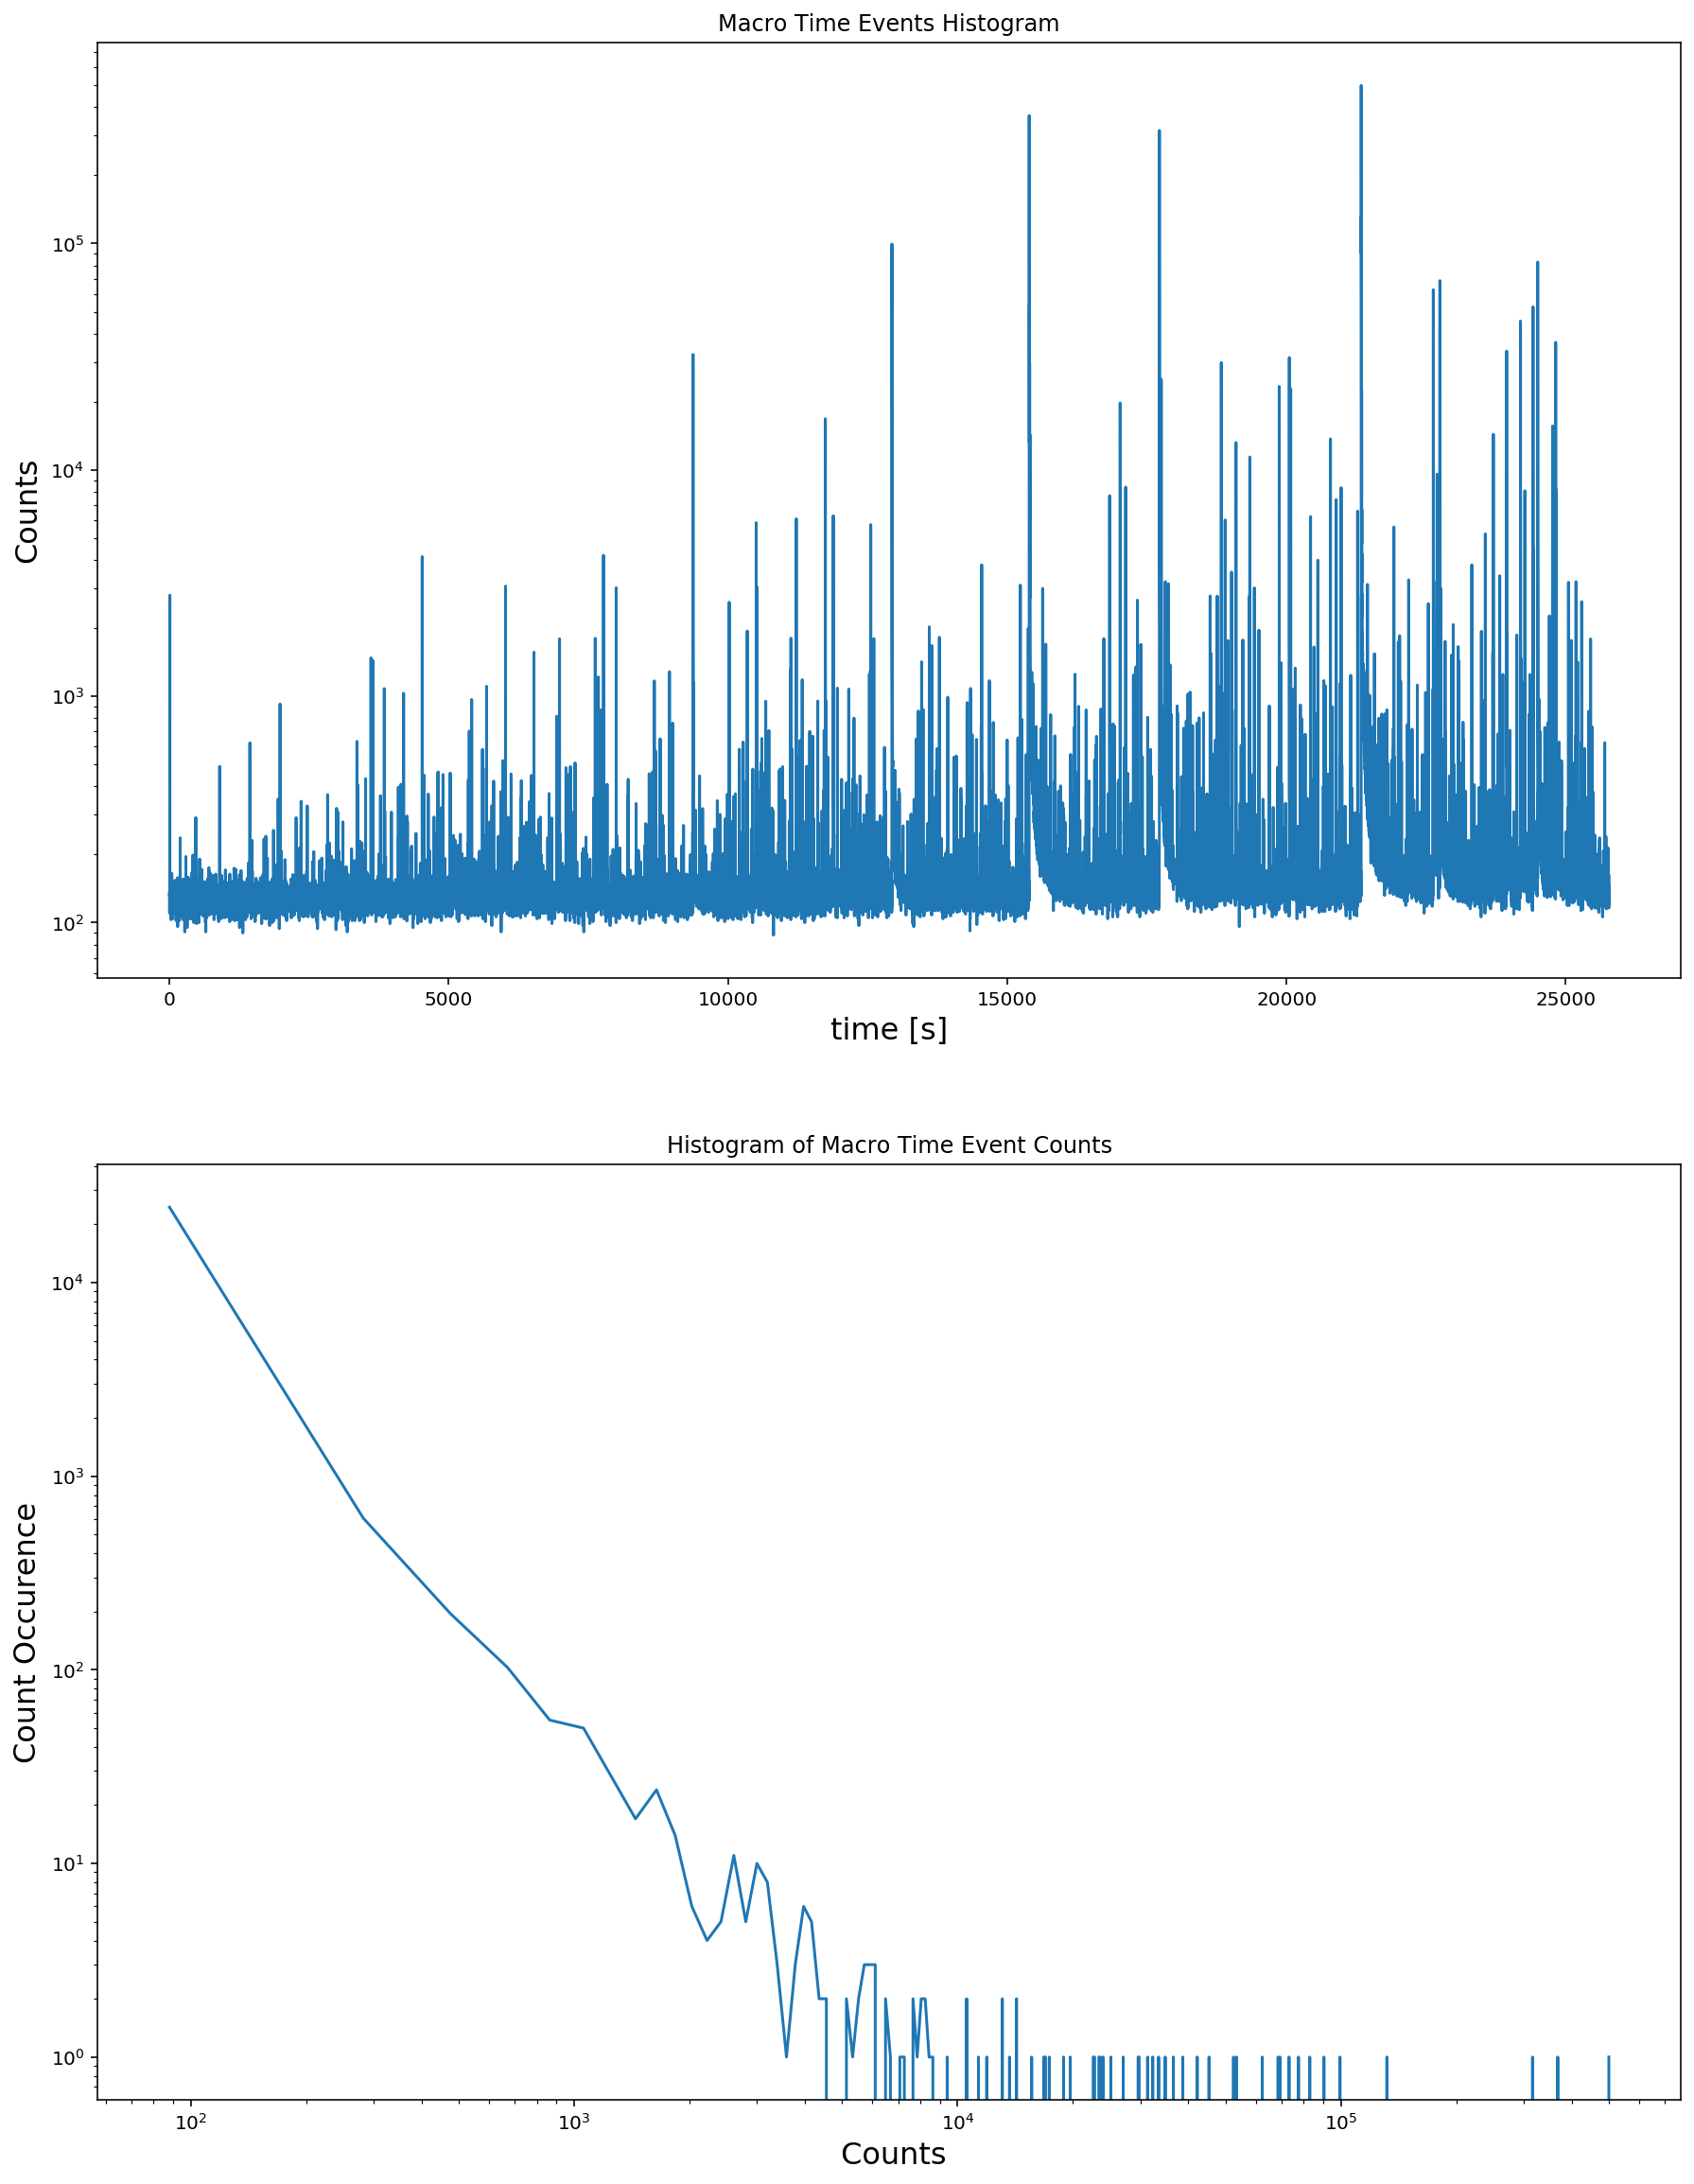

In [168]:
# Calculate macrotimes histogram
macrotimes_hist_c1 = np.histogram(macrotimes[np.where(markers == selected_marker)], bins = bins)
macrotimes_eventfreq = np.histogram(macrotimes_hist_c1[0], bins = int(bins/10))

fig, axs = plt.subplots(2)
#fig.suptitle('Histograms: Macro Time Clock Events')
fig.set_size_inches(15, 20)
axs[0].plot(macrotimes_hist_c1[1][:-1], macrotimes_hist_c1[0], '-')
axs[0].set(title = 'Macro Time Events Histogram', ylabel = 'Counts', xlabel = 'time [s]', yscale = 'log')#, xlim = (15000, 20000))
axs[1].plot(macrotimes_eventfreq[1][:-1], macrotimes_eventfreq[0])
axs[1].set(title = 'Histogram of Macro Time Event Counts', ylabel = 'Count Occurence', xlabel = ' Counts', xscale = 'log', yscale = 'log')
plt.show()

In [169]:
c1_selection = nanotimes[0:10000]
#ns_hist_c1 = np.histogram(nanotimes[np.where(markers == 0)], bins = 3214)
ns_hist_c1 = np.histogram(c1_selection, bins = 3214)
ns_hist_c2 = np.histogram(nanotimes[np.where(markers == 1)], bins = 3214)

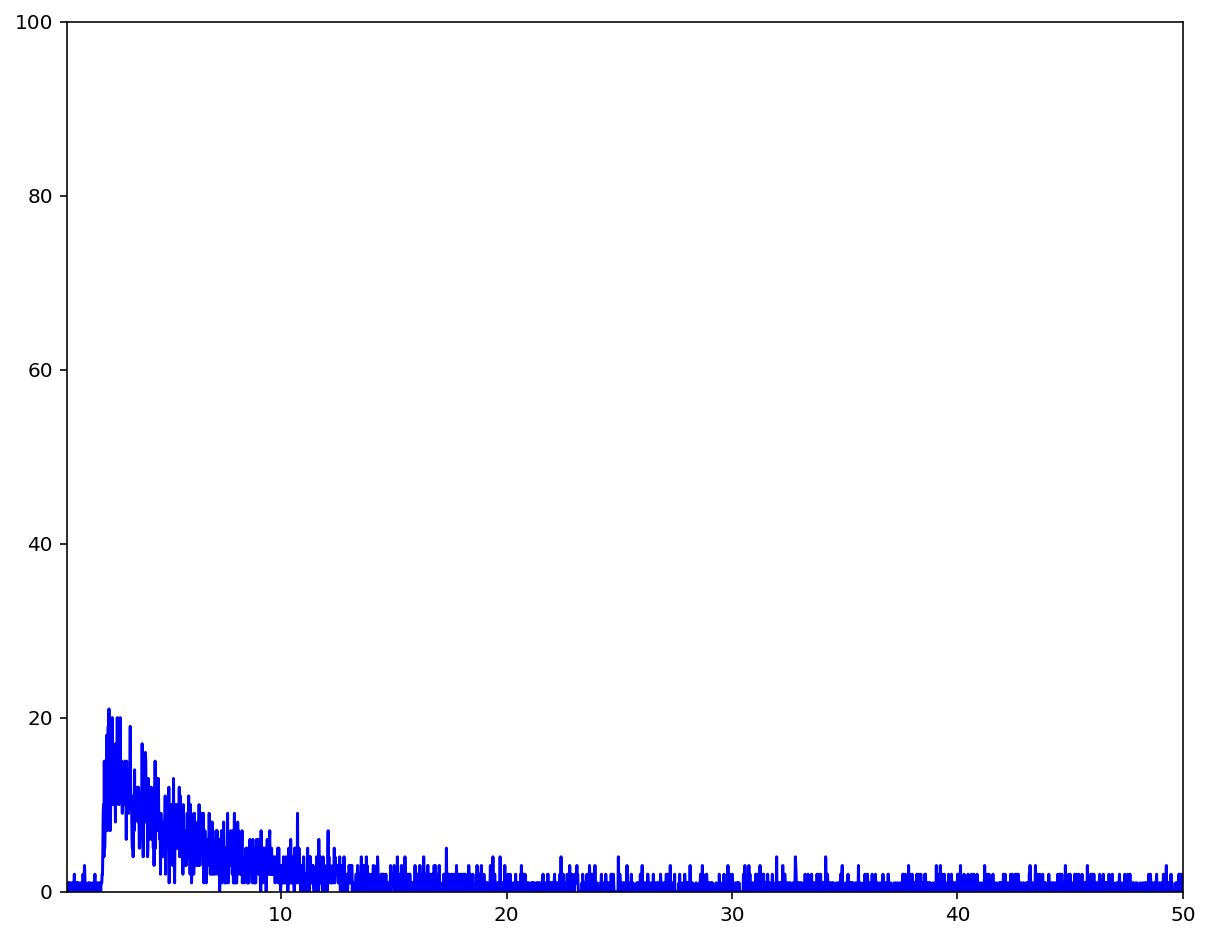

In [170]:
plt.plot(ns_hist_c1[1][:-1], ns_hist_c1[0], 'b-')
plt.xlim(0.5, 50)
plt.ylim(0, 100)
plt.yscale('linear')
plt.show()

## Notch Filter Test
The pulsed white light laser (WLL) of the Leica SP8 system was tested for laser pulse bleed-through using an hybrid detector and the HydraHarp V2 TCSPC system. Laser emission was set to $488 \ nm$ and the detection edge of the hydrid detector was shifted from $500 \ nm$ to $498 \ nm$, $495 \ nm$, $493 \ nm$, $490 \ nm$, $489 \ nm$, $488 \ nm$, and $485 \ nm$ (total detection range of $50 \ nm$). During the first repetition, the notch filter for $488 \ nm$ was used, in the second repetition no notch filter was used.

The readPTUData() function, defined above, returns macro time, nano time, marker, and header arrays. The nano times are put in a histogram and plotted using the matplotlib module. The effect of the notch filter is shown.

In [171]:
# With Notfch Filter
wNF_500 = np.array(readPTUData('../notebooks/data/Notch Filter Test/191214_NFTest_488_wNF_1/191214_NFTest_488_wNF_1_1.ptu'))
wNF_500_hist = np.histogram(wNF_500[1][np.where(wNF_500[2] == 0)], bins = 3214)

wNF_495 = np.array(readPTUData('../notebooks/data/Notch Filter Test/191214_NFTest_488_wNF_2/191214_NFTest_488_wNF_2_1.ptu'))
wNF_495_hist = np.histogram(wNF_495[1][np.where(wNF_495[2] == 0)], bins = 3214)

wNF_493 = np.array(readPTUData('../notebooks/data/Notch Filter Test/191214_NFTest_488_wNF_3/191214_NFTest_488_wNF_3_1.ptu'))
wNF_493_hist = np.histogram(wNF_493[1][np.where(wNF_493[2] == 0)], bins = 3214)

wNF_490 = np.array(readPTUData('../notebooks/data/Notch Filter Test/191214_NFTest_488_wNF_4/191214_NFTest_488_wNF_4_1.ptu'))
wNF_490_hist = np.histogram(wNF_490[1][np.where(wNF_490[2] == 0)], bins = 3214)

wNF_489 = np.array(readPTUData('../notebooks/data/Notch Filter Test/191214_NFTest_488_wNF_5/191214_NFTest_488_wNF_5_1.ptu'))
wNF_489_hist = np.histogram(wNF_489[1][np.where(wNF_489[2] == 0)], bins = 3214)

wNF_488 = np.array(readPTUData('../notebooks/data/Notch Filter Test/191214_NFTest_488_wNF_6/191214_NFTest_488_wNF_6_1.ptu'))
wNF_488_hist = np.histogram(wNF_488[1][np.where(wNF_488[2] == 0)], bins = 3214)

wNF_485 = np.array(readPTUData('../notebooks/data/Notch Filter Test/191214_NFTest_488_wNF_7/191214_NFTest_488_wNF_7_1.ptu'))
wNF_485_hist = np.histogram(wNF_485[1][np.where(wNF_485[2] == 0)], bins = 3214)



# Without Notch Filter
woNF_500 = np.array(readPTUData('../notebooks/data/Notch Filter Test/191214_NFTest_488_woNF_9/191214_NFTest_488_woNF_9_1.ptu'))
woNF_500_hist = np.histogram(woNF_500[1][np.where(woNF_500[2] == 0)], bins = 3214)

woNF_495 = np.array(readPTUData('../notebooks/data/Notch Filter Test/191214_NFTest_488_woNF_11/191214_NFTest_488_woNF_11_1.ptu'))
woNF_495_hist = np.histogram(woNF_495[1][np.where(woNF_495[2] == 0)], bins = 3214)

woNF_493 = np.array(readPTUData('../notebooks/data/Notch Filter Test/191214_NFTest_488_woNF_12/191214_NFTest_488_woNF_12_1.ptu'))
woNF_493_hist = np.histogram(woNF_493[1][np.where(woNF_493[2] == 0)], bins = 3214)

woNF_490 = np.array(readPTUData('../notebooks/data/Notch Filter Test/191214_NFTest_488_woNF_13/191214_NFTest_488_woNF_13_1.ptu'))
woNF_490_hist = np.histogram(woNF_490[1][np.where(woNF_490[2] == 0)], bins = 3214)

woNF_489 = np.array(readPTUData('../notebooks/data/Notch Filter Test/191214_NFTest_488_woNF_14/191214_NFTest_488_woNF_14_1.ptu'))
woNF_489_hist = np.histogram(woNF_489[1][np.where(woNF_489[2] == 0)], bins = 3214)

woNF_488 = np.array(readPTUData('../notebooks/data/Notch Filter Test/191214_NFTest_488_woNF_15/191214_NFTest_488_woNF_15_1.ptu'))
woNF_488_hist = np.histogram(woNF_488[1][np.where(woNF_488[2] == 0)], bins = 3214)

woNF_485 = np.array(readPTUData('../notebooks/data/Notch Filter Test/191214_NFTest_488_woNF_16/191214_NFTest_488_woNF_16_1.ptu'))
woNF_485_hist = np.histogram(woNF_485[1][np.where(woNF_485[2] == 0)], bins = 3214)

In [173]:
#for k in wNF_485[3]:
#    print(k, wNF_485[3][k])


[None, (0.1, 50000), Text(0.5, 0, 'nanotime [ns]')]

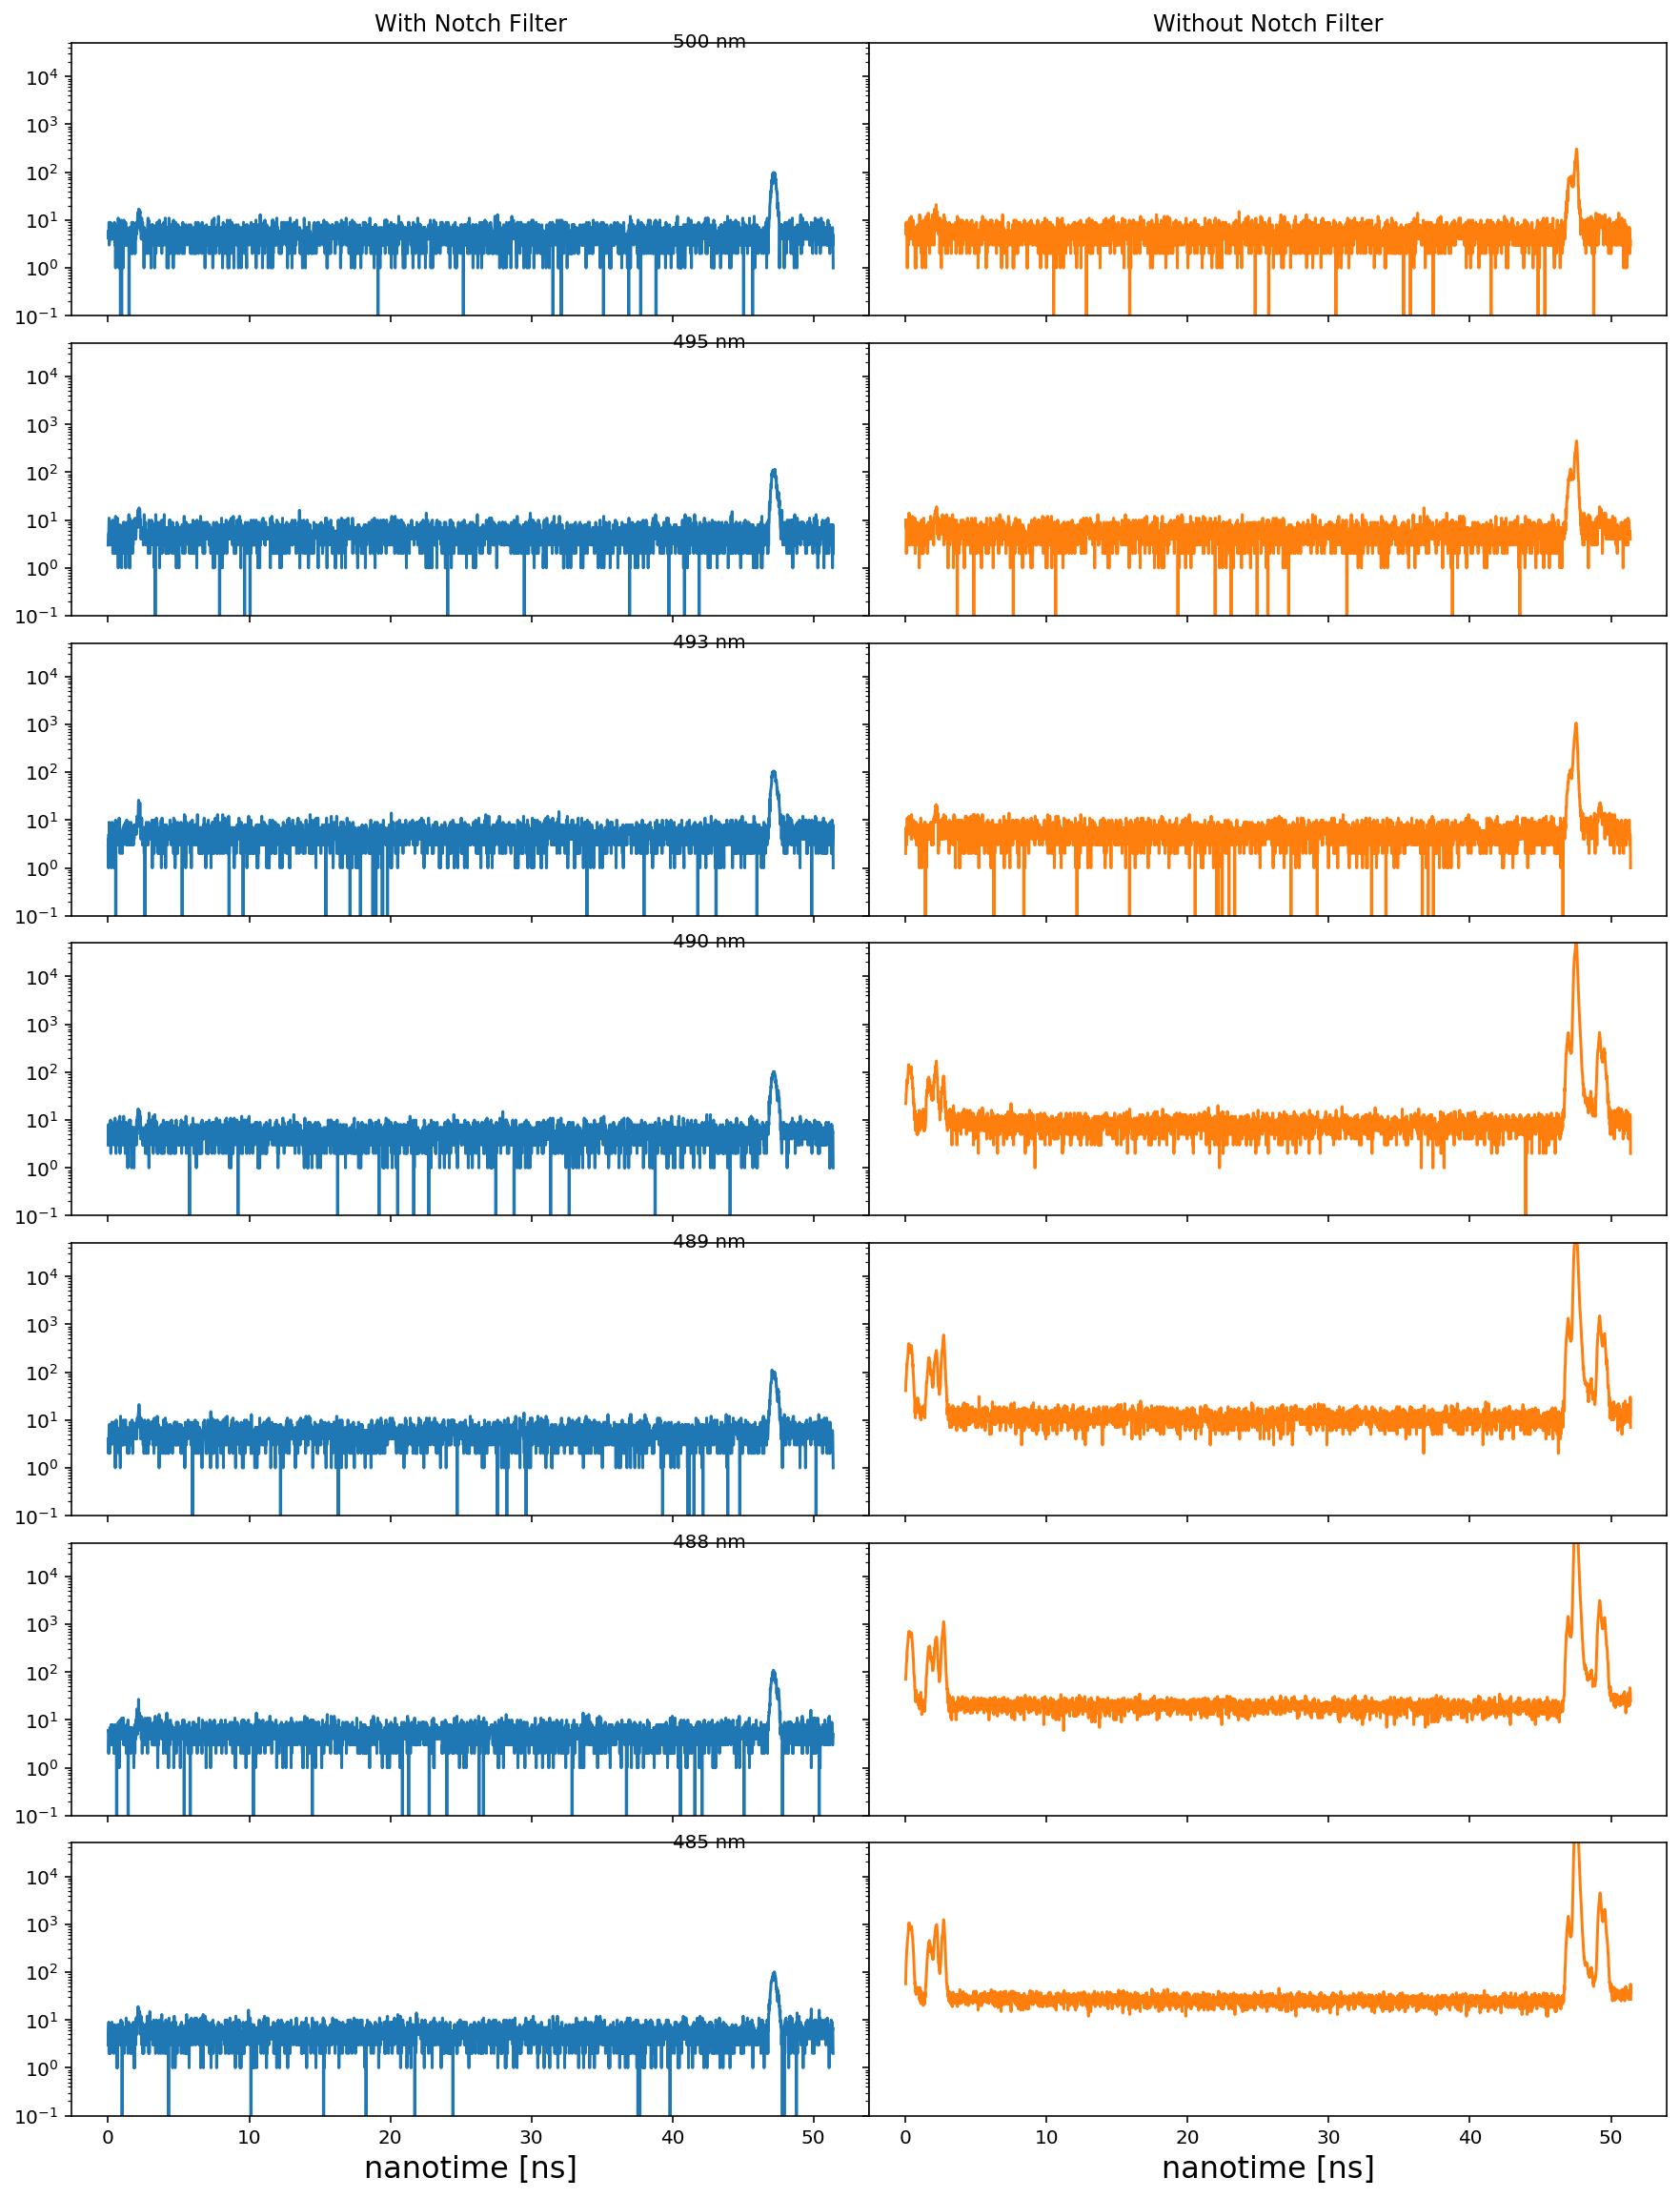

In [174]:
# Making subplots for peak visualization

yUpperLim = (0.1, 50000)
yscale_set = 'log'

fig, axs = plt.subplots(7, 2, sharex='col', sharey='row',
                        gridspec_kw={'hspace': 0.1, 'wspace': 0})
fig.set_size_inches(15, 20)

(ax1, ax2), (ax3, ax4), (ax5, ax6), (ax7, ax8), (ax9, ax10), (ax11, ax12), (ax13, ax14) = axs


ax1.plot(wNF_500_hist[1][:-1], wNF_500_hist[0])
ax1.set(ylim = yUpperLim, yscale = yscale_set)
ax1.set_title('With Notch Filter')
ax1.text(40, (0.8*yUpperLim[1]), '500 nm')
ax2.plot(woNF_500_hist[1][:-1], woNF_500_hist[0], 'tab:orange')
ax2.set(ylim = yUpperLim, yscale = yscale_set)
ax2.set_title('Without Notch Filter')


ax3.plot(wNF_495_hist[1][:-1], wNF_495_hist[0])
ax3.set(ylim = yUpperLim, yscale = yscale_set)
ax3.text(40, (0.8*yUpperLim[1]), '495 nm')
ax4.plot(woNF_495_hist[1][:-1], woNF_495_hist[0], 'tab:orange')
ax4.set(ylim = yUpperLim, yscale = yscale_set)

ax5.plot(wNF_493_hist[1][:-1], wNF_493_hist[0])
ax5.set(ylim = yUpperLim, yscale = yscale_set)
ax5.text(40, (0.8*yUpperLim[1]), '493 nm')
ax6.plot(woNF_493_hist[1][:-1], woNF_493_hist[0], 'tab:orange')
ax6.set(ylim = yUpperLim, yscale = yscale_set)

ax7.plot(wNF_490_hist[1][:-1], wNF_490_hist[0])
ax7.set(ylim = yUpperLim, yscale = yscale_set)
ax7.text(40, (0.8*yUpperLim[1]), '490 nm')
ax8.plot(woNF_490_hist[1][:-1], woNF_490_hist[0], 'tab:orange')
ax8.set(ylim = yUpperLim, yscale = yscale_set)

ax9.plot(wNF_489_hist[1][:-1], wNF_489_hist[0])
ax9.set(ylim = yUpperLim, yscale = yscale_set)
ax9.text(40, (0.8*yUpperLim[1]), '489 nm')
ax10.plot(woNF_489_hist[1][:-1], woNF_489_hist[0], 'tab:orange')
ax10.set(ylim = yUpperLim, yscale = yscale_set)

ax11.plot(wNF_488_hist[1][:-1], wNF_488_hist[0])
ax11.set(ylim = yUpperLim, yscale = yscale_set)
ax11.text(40, (0.8*yUpperLim[1]), '488 nm')
ax12.plot(woNF_488_hist[1][:-1], woNF_488_hist[0], 'tab:orange')
ax12.set(ylim = yUpperLim, yscale = yscale_set)

ax13.plot(wNF_485_hist[1][:-1], wNF_485_hist[0])
ax13.set(ylim = yUpperLim, xlabel = 'nanotime [ns]', yscale = yscale_set)
ax13.text(40, (0.8*yUpperLim[1]), '485 nm')
ax14.plot(woNF_485_hist[1][:-1], woNF_485_hist[0], 'tab:orange')
ax14.set(ylim = yUpperLim, xlabel = 'nanotime [ns]', yscale = yscale_set)


## Image Reconstruction of Notch Filter Test Series

In [189]:
# Functions for image reconstruction
#@jit(nopython=True, cache=True)
def buildFLIMArray(recordarray, channel, linesinfile, pixelsx, pixelsy, globRes, timeRes, spatialBinning, temporalBinning):
    '''
    buildFLIMArray(
    - recordarray: 3 x numRec NumPy array, holds raw photon data and system events, see readPTUdata(path)
    - channel: int; which channel to reconstruct the flimarray from
    - pixelsx: original image dimension in X, stored in FLIMInfo
    - pixelsy: original image dimension in Y, stored in FLIMInfo
    - globRes: global measurment of nanotime, stored in FLIMInfo, in ns, 51 ns for 20 MHz laser pulse frequency
    - timeRes: nanotime resolution of TCSPC device, in ps
    - spatialBinning: user-defined binning factor of image, calculated as 2**factor
    - temporalBinning: user-defined binning factor for fluorescence decay histogram
    )
    '''

    eventCounter = int(0)  # Keeps track of photon / marker events while looping through data
    lineCounter = 0  # Stores current scan line numbers
    frameCounter = 0  # Stores current frame number
    # How many frames are in the image; assume square format
    framesInFile = linesinfile / pixelsx
    # Number of TCSPC bins based on time between pulses and TCSPC time resolution
    decayBins = math.ceil((globRes / timeRes)/(2**temporalBinning))
    globalResolution = globRes * 10E8  # time between pulses in ns
    timeResolution = timeRes * 10E9  # TCSPC time resolution in nss

    binningFactor = 2**spatialBinning

    lineStart = 0
    lineStop = 0
    pixelTime = 0  # Tmp variable for storing time/pixel when line start and stop macro times are determined; needed to assign photons to y pixels in a line

    # Set to True when last scan line was evaluated and frameCounter >= framesInFile
    lastLine = False
    # Set to True when line start marker is found (= 65), starts photon assignments to y-pixels in a line (x); set to False when line stop marker is found (=66)
    lineActive = False

    # List storing photon macrotimes when line is active to determine y-pixel position of photon
    tmpEvents = [np.float64(x) for x in range(0)]
    # List storing photon nanotimes to assign to 3D-FLIM array in x-y position
    tmpNano = [np.float64(x) for x in range(0)]
    tmpMarker = 0  # Holds marker value for one loop iteration
    tmpMacro = 0  # Holds macrotime value for one loop iteration
    tmpNanotime = 0  # Holds nanotime value for one loop iteration
    diff = 0  # Stores difference between photon macro time and line start to determine photon y-position
    # Count out-of-range photons (photons with macrotime below or above line time difference)
    oorPhotons = 0

    nPixelX = int(pixelsx / binningFactor)
    nPixelY = int(pixelsy / binningFactor)

    pixelIDX = 0  # Current x position in image
    pixelIDY = 0  # Current y position in image

    flimarray = np.zeros((nPixelX, nPixelY, decayBins), dtype=np.uint16)
    # 2D array for intensity image
    intensityImage = np.zeros((nPixelX, nPixelY), dtype=np.uint16)

    while(lastLine == False):
        tmpMarker = recordarray[2][eventCounter]

        if(tmpMarker == 65):  # Event is line start marker
            lineActive = True  # Starting line evaluation (next while loop)
            # Store line start time
            lineStart = recordarray[0][eventCounter]
            eventCounter += 1
            continue  # Skip this loop iteration

        if(tmpMarker == 0 or tmpMarker == 1 or tmpMarker == 2 or tmpMarker == 3):
            oorPhotons += 1

        while(lineActive == True):
            tmpMarker = recordarray[2][eventCounter]
            tmpMacro = recordarray[0][eventCounter]
            tmpNanotime = recordarray[1][eventCounter]

            if(tmpMarker == channel):
                tmpEvents.append(tmpMacro)
                tmpNano.append(tmpNanotime)
            elif(tmpMarker == 66):
                lineActive = False
                lineStop = tmpMacro
                pixelTime = (lineStop - lineStart) / (nPixelY)

                # Build intensity image and FLIM array from photon macro times
                for i in range(0, len(tmpEvents)):
                    diff = tmpEvents[i] - lineStart
                    pixelIDY = math.floor(diff / pixelTime)
                    binID = math.floor((tmpNano[i]/globalResolution)*decayBins)

                    if(pixelIDY < 0 or pixelIDY > nPixelY):
                        #oorPhotons = oorPhotons + 1
                        if(pixelIDY < 0):
                            pixelIDY = 0
                        elif(pixelIDY > (nPixelY - 1)):
                            pixelIDY = nPixelY - 1

                    intensityImage[math.floor(pixelIDX)][pixelIDY] += 1
                    flimarray[math.floor(pixelIDX)][pixelIDY][binID] += 1

                pixelIDX = pixelIDX + (1/binningFactor)
                lineCounter = lineCounter + 1
                tmpEvents = [np.float64(x) for x in range(0)]
                tmpNano = [np.float64(x) for x in range(0)]

            eventCounter += 1

        if(lineCounter > (pixelsx - 1)):
            frameCounter = frameCounter + 1
            pixelIDX = 0
            lineCounter = 0

        if(frameCounter >= framesInFile):
            lastLine = True

        eventCounter += 1

    print("Assigned photons to pixels.\n",
          (oorPhotons / np.sum(intensityImage))*100,
          "% of photons were out of range... Total:", oorPhotons, "of", np.sum(intensityImage), "photons.")

    return flimarray, intensityImage




#@jit(nopython=True)
def countLines(recordarray):
    '''
    Function: countLines(
    - recordarray: 4 x numRec NumPy array, holds raw photon data and system events
    )
    
    - Counts number of line start (marker == 65) and line stop (marker == 66) events in raw photon data
    - Purpose: check data integrity
    '''

    numLinesStart = np.sum(recordarray[2] == 65)
    numLinesStop = np.sum(recordarray[2] == 66)
    
    if(numLinesStart != numLinesStop):
        print("Line start and stop numbers not equal. Corrupted file?")
    
    return numLinesStart

In [190]:
wNF_500[3]['LinesInFile'] = countLines(wNF_500)
print(wNF_500[3]['LinesInFile'])

12800


In [192]:

flimarray, intimage = buildFLIMArray(wNF_500,
                                     0,
                                     wNF_500[3]['LinesInFile'],
                                     wNF_500[3]['PixelsX'],
                                     wNF_500[3]['PixelsY'],
                                     wNF_500[3]['GlobalResolution'],
                                     wNF_500[3]['Resolution'],
                                     0,
                                     0)

IndexError: index 128 is out of bounds for axis 0 with size 128